<a href="https://colab.research.google.com/github/sallahvoice/quant-notebook/blob/main/quant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

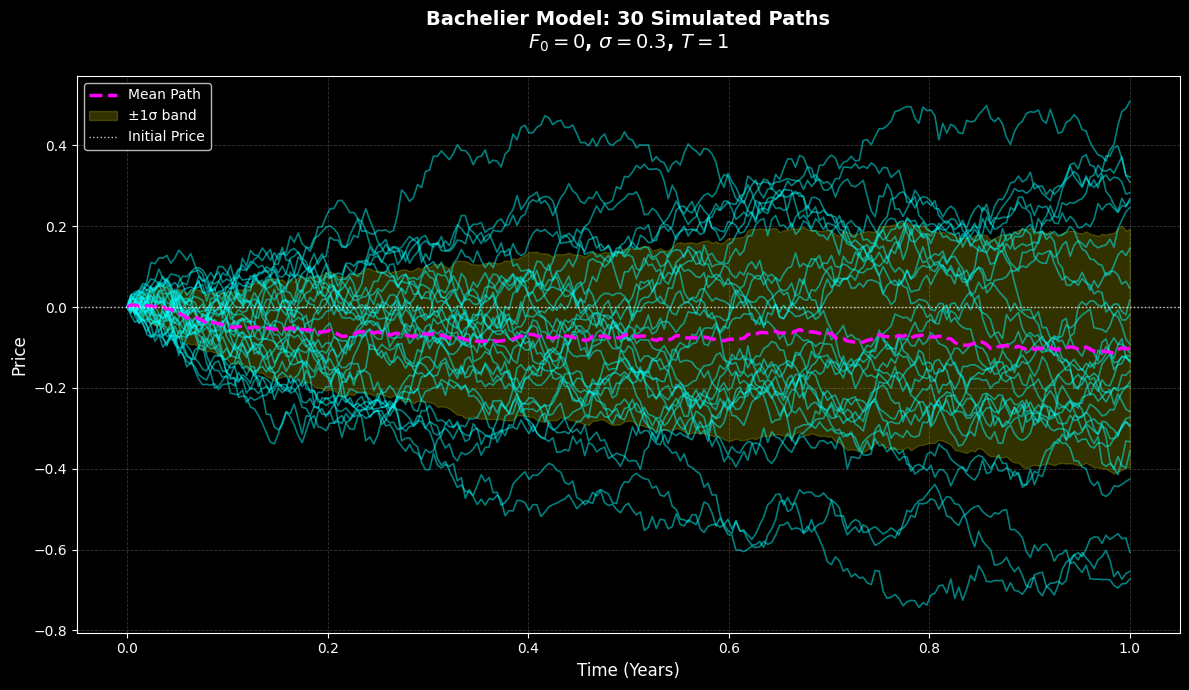

In [ ]:
from matplotlib.lines import lineStyles
import numpy as np
import matplotlib.pyplot as plt

def bachelier(F_0, sigma, T, steps, n):
  paths = []
  for i in range(n):
    prices = [F_0]
    dt = T/steps
    t_index = 0
    while(t_index + dt < T):
      t_index += dt
      prices.append(prices[-1] + sigma * np.random.normal(0, 1) * np.sqrt(dt))
    paths.append(prices)
  return paths

F_0 = 0
sigma = 0.3
T = 1
n_steps = 252
n_paths = 30

simulations = bachelier(F_0, sigma, T, n_steps, n_paths)
t = np.linspace(0, T, len(simulations[0]))

fig, ax = plt.subplots(figsize=(12, 7))

for sim in simulations:
  ax.plot(t, sim, color="cyan", linewidth=1.2, alpha=0.5)

mean_path = np.mean(simulations, axis=0)
ax.plot(t, mean_path, color="magenta", linewidth=2.5, linestyle="--", label="Mean Path")

std_path = np.std(simulations, axis=0)
ax.fill_between(t, mean_path - std_path, mean_path + std_path, color="yellow", label="±1σ band", alpha=0.2)


plt.style.use("dark_background")
ax.set_title(f'Bachelier Model: {n_paths} Simulated Paths\n$F_0={F_0}$, $\\sigma={sigma}$, $T={T}$', fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Time (Years)", fontsize=12)
ax.set_ylabel("Price", fontsize=12)
ax.axhline(y=F_0, color="white", linestyle=":", linewidth=1, alpha=0.8, label="Initial Price")
ax.grid(True, linestyle="--", alpha=0.2, linewidth=0.6)
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()
